# Laboratorio 2: Armado de un esquema de aprendizaje automático

En el laboratorio final se espera que puedan poner en práctica los conocimientos adquiridos en el curso, trabajando con un conjunto de datos de clasificación.

El objetivo es que se introduzcan en el desarrollo de un esquema para hacer tareas de aprendizaje automático: selección de un modelo, ajuste de hiperparámetros y evaluación.

El conjunto de datos a utilizar está en `./data/loan_data.csv`. Si abren el archivo verán que al principio (las líneas que empiezan con `#`) describen el conjunto de datos y sus atributos (incluyendo el atributo de etiqueta o clase).

Se espera que hagan uso de las herramientas vistas en el curso. Se espera que hagan uso especialmente de las herramientas brindadas por `scikit-learn`.

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Agregar las librerías que hagan falta
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

## Carga de datos y división en entrenamiento y evaluación

La celda siguiente se encarga de la carga de datos (haciendo uso de pandas). Estos serán los que se trabajarán en el resto del laboratorio.

In [17]:
#dataset = pd.read_csv("./data/loan_data.csv", comment="#")
dataset = pd.read_csv("https://raw.githubusercontent.com/DiploDatos/IntroduccionAprendizajeAutomatico/master/data/loan_data.csv", comment="#")


# División entre instancias y etiquetas
X, y = dataset.iloc[:, 1:], dataset.TARGET

# división entre entrenamiento y evaluación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   TARGET   1854 non-null   int64  
 1   LOAN     1854 non-null   int64  
 2   MORTDUE  1854 non-null   float64
 3   VALUE    1854 non-null   float64
 4   YOJ      1854 non-null   float64
 5   DEROG    1854 non-null   float64
 6   DELINQ   1854 non-null   float64
 7   CLAGE    1854 non-null   float64
 8   NINQ     1854 non-null   float64
 9   CLNO     1854 non-null   float64
 10  DEBTINC  1854 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 159.5 KB


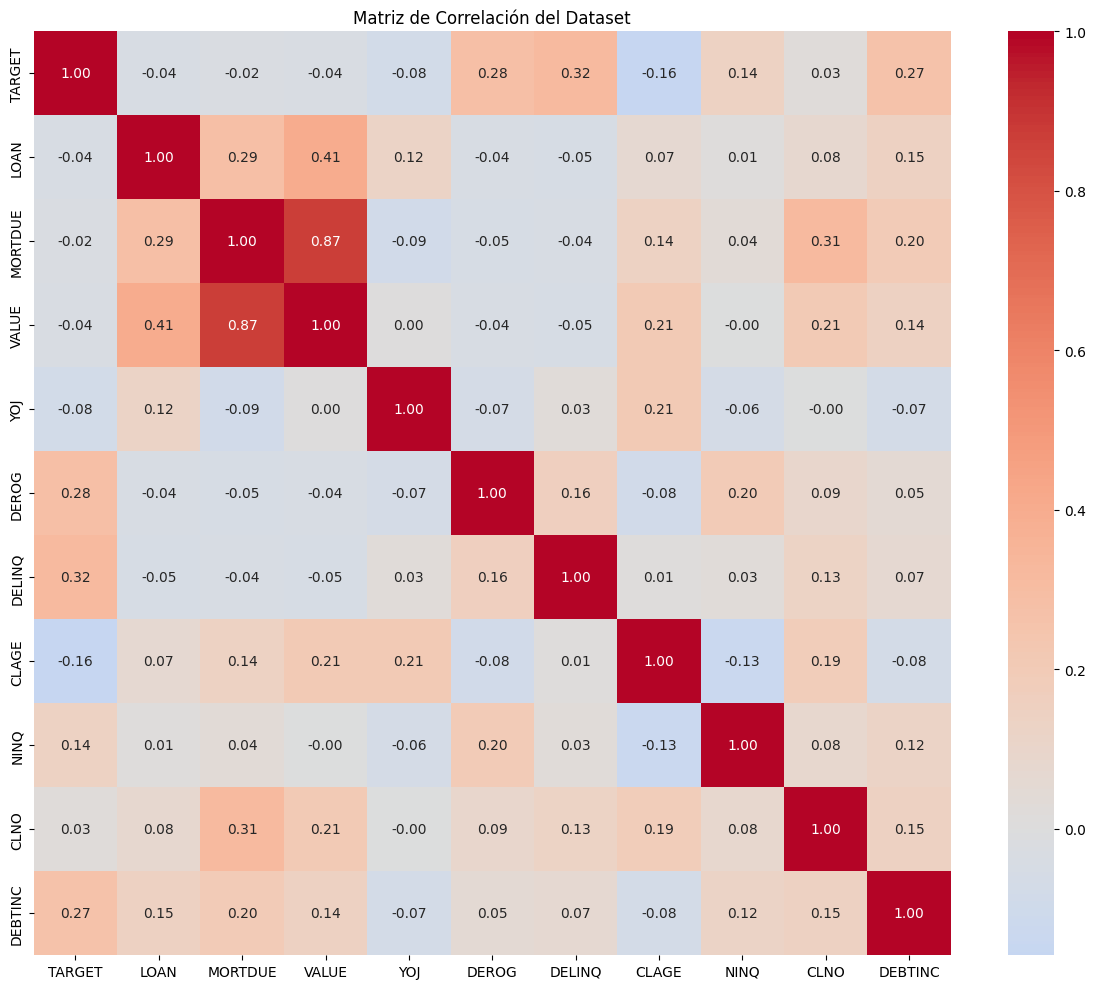

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear gráfico de correlación
plt.figure(figsize=(12, 10))
correlation_matrix = dataset.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", center=0)
plt.title("Matriz de Correlación del Dataset")
plt.tight_layout()
plt.show()


Documentación:

- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

1. El conjunto de datos `loan_data.csv` contiene información sobre préstamos y si estos fueron pagados completamente o no.

2. La variable objetivo a predecir es `TARGET`. Un valor de 1 indica que el préstamo fue pagado completamente, mientras que un valor de 0 indica que el préstamo no fue pagado (es decir, hubo un incumplimiento).

3. La información disponible para hacer la predicción incluye tanto atributos numéricos como categóricos, que describen las características del préstamo y del prestatario. Estos atributos son:

*   `ID`: Identificador único para cada préstamo.
*   `AMOUNT`: Monto del préstamo solicitado.
*   `ANNUAL_PERCENTAGE_RATE`: Tasa de porcentaje anual del préstamo.
*   `TERM_IN_YEARS`: Duración del préstamo en años.
*   `EMPLOYMENT_LENGTH`: Duración del empleo del prestatario en años (representado como una categoría, por ejemplo, "<1 year", "1 year", "10+ years").
*   `HOME_OWNERSHIP`: Situación de la vivienda del prestatario (por ejemplo, "RENT", "OWN", "MORTGAGE").
*   `REASON`: Razón por la que se solicitó el préstamo (por ejemplo, "credit_card", "debt_consolidation").
*   `STATE`: Estado de residencia del prestatario.
*   `DEBT_TO_INCOME_RATIO`: Relación deuda-ingreso del prestatario.
*   `NUMBER_OF_ACCOUNTS`: Número de cuentas de crédito abiertas.
*   `DELINQUENCIES`: Número de pagos atrasados en el historial crediticio.
*   `PUBLIC_RECORDS`: Número de registros públicos negativos (por ejemplo, bancarrotas, embargos).
*   `YEARS_OF_CREDIT_HISTORY`: Número de años de historial crediticio.
*   `INQUIRIES_LAST_6_MONTHS`: Número de consultas de crédito en los últimos 6 meses.
*   `NUMBER_OF_OPEN_CREDIT_LINES`: Número de líneas de crédito abiertas.
*   `TOTAL_CREDIT_LIMIT`: Límite total de crédito disponible.
*   `REVOLVING_BALANCE`: Saldo pendiente en las líneas de crédito rotatorio.
*   `REVOLVING_UTILIZATION`: Tasa de utilización del crédito rotatorio.
*   `FULLY_PAID`: (Este parece ser el mismo que TARGET, indicando si el préstamo fue pagado).

4. Los atributos que podrian ser determinantes para la predicción del incumplimiento son:

*   `DEBT_TO_INCOME_RATIO`: Un alto DTI sugiere que el prestatario tiene dificultades para manejar su deuda actual, lo que podría aumentar el riesgo de incumplimiento.
*   `DELINQUENCIES` y `PUBLIC_RECORDS`: Historiales de pagos atrasados o registros públicos negativos son fuertes indicadores de riesgo crediticio.
*   `YEARS_OF_CREDIT_HISTORY`: Un historial crediticio más largo y positivo generalmente se asocia con un menor riesgo.
*   `INQUIRIES_LAST_6_MONTHS`: Un alto número de consultas recientes puede indicar que el prestatario está buscando mucho crédito, posiblemente debido a dificultades financieras.
*   `REVOLVING_UTILIZATION`: Una alta utilización del crédito rotatorio puede sugerir que el prestatario está cerca de su límite de crédito, lo que podría ser un signo de estrés financiero.
*   `EMPLOYMENT_LENGTH`: Una mayor estabilidad laboral podría correlacionarse con una mayor capacidad de pago.
*   `ANNUAL_PERCENTAGE_RATE`: Tasas de interés más altas pueden reflejar un mayor riesgo percibido por el prestamista.

In [20]:
X_train

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
1240,9400,92340.0,125451.0,7.0,0.0,0.0,129.113725,1.0,22.0,36.349975
1183,14800,43983.0,60826.0,4.0,1.0,1.0,113.897967,1.0,9.0,27.108082
692,20100,59726.0,79982.0,8.0,1.0,0.0,74.210759,2.0,28.0,36.846922
871,25200,73168.0,93608.0,9.0,0.0,0.0,151.121480,0.0,21.0,35.590327
1353,17000,70039.0,100993.0,7.0,0.0,0.0,261.911317,1.0,11.0,36.564330
...,...,...,...,...,...,...,...,...,...,...
835,15900,48563.0,64679.0,4.0,0.0,0.0,156.101381,2.0,12.0,27.808547
1216,27500,150666.0,192346.0,3.0,0.0,0.0,177.871473,0.0,17.0,39.978650
1653,12800,54151.0,83828.0,13.0,0.0,0.0,132.160270,0.0,16.0,23.477426
559,21300,63263.0,94180.0,1.0,0.0,0.0,138.348455,1.0,22.0,35.549295


## Ejercicio 2: Predicción con Modelos Lineales

En este ejercicio se entrenarán modelos lineales de clasificación para predecir la variable objetivo.

Para ello, deberán utilizar la clase SGDClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/sgd.html
- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html


In [21]:
from sklearn.linear_model import SGDClassifier

classifier = SGDClassifier(random_state=0)
classifier.fit(X_train, y_train)


SGDClassifier(random_state=0)

### Ejercicio 2.1: SGDClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador SGDClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

=== EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO ===
Accuracy: 0.8307
Precision: 0.6901
Recall: 0.8307
F1-Score: 0.7539

Matriz de Confusión (Entrenamiento):
[[1232    0]
 [ 251    0]]

=== EVALUACIÓN EN CONJUNTO DE EVALUACIÓN (TEST) ===
Accuracy: 0.8437
Precision: 0.7118
Recall: 0.8437
F1-Score: 0.7721

Matriz de Confusión (Test):
[[313   0]
 [ 58   0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


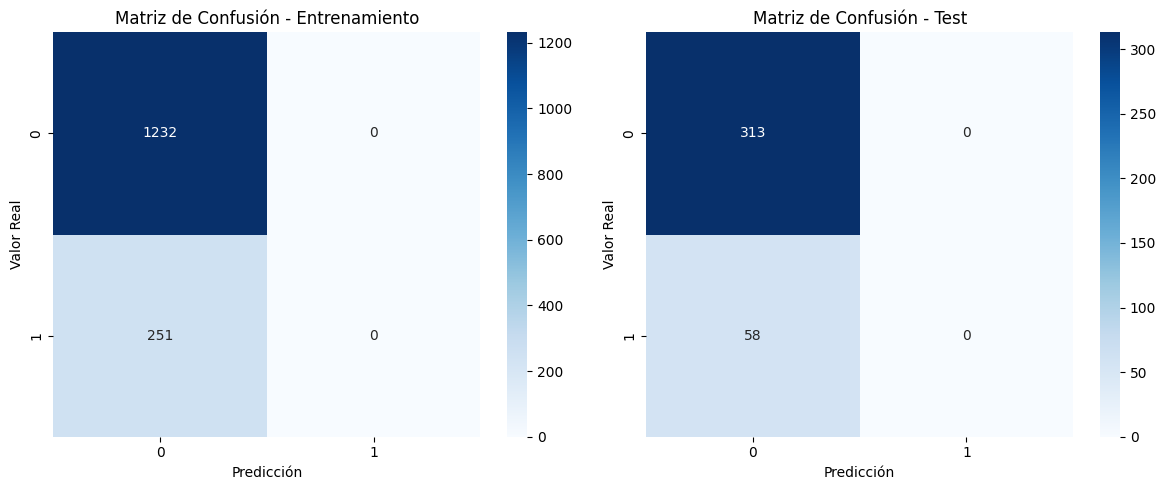


=== REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ===
              precision    recall  f1-score   support

   Rechazado       0.84      1.00      0.92       313
    Otorgado       0.00      0.00      0.00        58

    accuracy                           0.84       371
   macro avg       0.42      0.50      0.46       371
weighted avg       0.71      0.84      0.77       371



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [22]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

classifier = SGDClassifier(max_iter=1000, random_state=42)
# , loss='log_loss', penalty='l2' , tol=1e-3
classifier.fit(X_train, y_train)

y_train_pred = classifier.predict(X_train)

y_test_pred = classifier.predict(X_test)

print("=== EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO ===")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred, average='weighted'):.4f}")

print("\nMatriz de Confusión (Entrenamiento):")
cm_train = confusion_matrix(y_train, y_train_pred)
print(cm_train)

print("\n" + "="*50)
print("=== EVALUACIÓN EN CONJUNTO DE EVALUACIÓN (TEST) ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")

print("\nMatriz de Confusión (Test):")
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

# Visualización de las matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión para entrenamiento
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Matriz de Confusión - Entrenamiento')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Valor Real')

# Matriz de confusión para test
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Matriz de Confusión - Test')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ===")
print(classification_report(y_test, y_test_pred, target_names=['Rechazado', 'Otorgado']))



### Ejercicio 2.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del SGDClassifier. Como mínimo, probar diferentes funciones de loss, tasas de entrenamiento y tasas de regularización.

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión

Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

## Ejercicio 3: Árboles de Decisión

En este ejercicio se entrenarán árboles de decisión para predecir la variable objetivo.

Para ello, deberán utilizar la clase DecisionTreeClassifier de scikit-learn.

Documentación:
- https://scikit-learn.org/stable/modules/tree.html
  - https://scikit-learn.org/stable/modules/tree.html#tips-on-practical-use
- https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
- https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html

### Ejercicio 3.1: DecisionTreeClassifier con hiperparámetros por defecto

Entrenar y evaluar el clasificador DecisionTreeClassifier usando los valores por omisión de scikit-learn para todos los parámetros. Únicamente **fijar la semilla aleatoria** para hacer repetible el experimento.

Evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


[Text(0.8616488597007123, 0.9782608695652174, 'DEBTINC <= 43.681\ngini = 0.281\nsamples = 1483\nvalue = [1232, 251]\nclass = Rechazado'),
 Text(0.7567552113964582, 0.9347826086956522, 'DELINQ <= 1.5\ngini = 0.227\nsamples = 1409\nvalue = [1225, 184]\nclass = Rechazado'),
 Text(0.8092020355485852, 0.9565217391304348, 'True  '),
 Text(0.6285205515258446, 0.8913043478260869, 'DEROG <= 1.5\ngini = 0.189\nsamples = 1313\nvalue = [1174, 139]\nclass = Rechazado'),
 Text(0.48706136051754556, 0.8478260869565217, 'CLAGE <= 173.132\ngini = 0.169\nsamples = 1274\nvalue = [1155, 119]\nclass = Rechazado'),
 Text(0.2836045219891525, 0.8043478260869565, 'VALUE <= 84241.5\ngini = 0.249\nsamples = 612\nvalue = [523, 89]\nclass = Rechazado'),
 Text(0.17120825981833626, 0.7608695652173914, 'LOAN <= 16850.0\ngini = 0.345\nsamples = 257\nvalue = [200, 57]\nclass = Rechazado'),
 Text(0.09148532967392015, 0.717391304347826, 'VALUE <= 50823.0\ngini = 0.413\nsamples = 168\nvalue = [119, 49]\nclass = Rechazado')

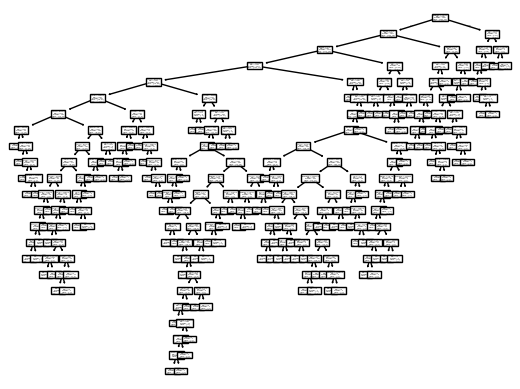

In [23]:
from sklearn import tree


dataframe_TreeClassifier = tree.DecisionTreeClassifier(random_state=42)
dataframe_TreeClassifier.fit(X_train, y_train)
y_train_predicted_tree = dataframe_TreeClassifier.predict(X_train)
y_test_predicted_tree = dataframe_TreeClassifier.predict(X_test)

tree.plot_tree(dataframe_TreeClassifier,
               feature_names=X_train.columns,  class_names=['Rechazado', 'Otorgado'])


In [24]:
print(f"accuracy: {accuracy_score(y_train, y_train_predicted_tree):.4f}")
print(f"preccision: { precision_score(y_train, y_train_predicted_tree):.4f}")
print(f"recall: {recall_score(y_train, y_train_predicted_tree):.4f}")
print(f"f1-score: {f1_score(y_train, y_train_predicted_tree):.4f}")

accuracy: 1.0000
preccision: 1.0000
recall: 1.0000
f1-score: 1.0000


### Ejercicio 3.2: Ajuste de Hiperparámetros

Seleccionar valores para los hiperparámetros principales del DecisionTreeClassifier. Como mínimo, probar diferentes criterios de partición (criterion), profundidad máxima del árbol (max_depth), y cantidad mínima de samples por hoja (min_samples_leaf).

Para ello, usar grid-search y 5-fold cross-validation sobre el conjunto de entrenamiento para explorar muchas combinaciones posibles de valores.

Reportar accuracy promedio y varianza para todas las configuraciones.

Para la mejor configuración encontrada, evaluar sobre el conjunto de **entrenamiento** y sobre el conjunto de **evaluación**, reportando:
- Accuracy
- Precision
- Recall
- F1
- matriz de confusión


Documentación:
- https://scikit-learn.org/stable/modules/grid_search.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

[Text(0.6544117647058824, 0.9166666666666666, 'DEBTINC <= 43.681\ngini = 0.281\nsamples = 100.0%\nvalue = [0.831, 0.169]\nclass = Rechazado'),
 Text(0.4264705882352941, 0.75, 'DELINQ <= 1.5\ngini = 0.227\nsamples = 95.0%\nvalue = [0.869, 0.131]\nclass = Rechazado'),
 Text(0.5404411764705882, 0.8333333333333333, 'True  '),
 Text(0.23529411764705882, 0.5833333333333334, 'DEROG <= 1.5\ngini = 0.189\nsamples = 88.5%\nvalue = [0.894, 0.106]\nclass = Rechazado'),
 Text(0.11764705882352941, 0.4166666666666667, 'CLAGE <= 173.132\ngini = 0.169\nsamples = 85.9%\nvalue = [0.907, 0.093]\nclass = Rechazado'),
 Text(0.058823529411764705, 0.25, 'VALUE <= 84241.5\ngini = 0.249\nsamples = 41.3%\nvalue = [0.855, 0.145]\nclass = Rechazado'),
 Text(0.029411764705882353, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.08823529411764706, 0.08333333333333333, '\n  (...)  \n'),
 Text(0.17647058823529413, 0.25, 'DEBTINC <= 12.867\ngini = 0.087\nsamples = 44.6%\nvalue = [0.955, 0.045]\nclass = Rechazado'),
 Text

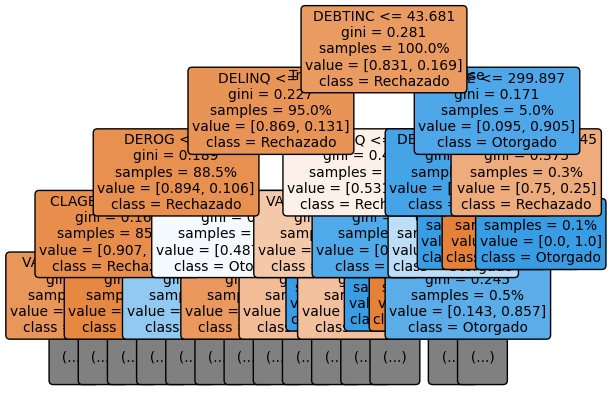

In [30]:
dataframe_TreeClassifier = tree.DecisionTreeClassifier(random_state=42)
dataframe_TreeClassifier.fit(X_train, y_train)
y_train_predicted_tree = dataframe_TreeClassifier.predict(X_train)
y_test_predicted_tree = dataframe_TreeClassifier.predict(X_test)

tree.plot_tree(dataframe_TreeClassifier,
               feature_names=X_train.columns,  # Nombres de las características
               class_names=['Rechazado', 'Otorgado'],  # Nombres de las clases
               filled=True,  # Colorear los nodos según la clase
               rounded=True,  # Esquinas redondeadas
               max_depth=4,  # Limitar profundidad mostrada (para evitar demasiado detalle)
               fontsize=10,  # Tamaño de fuente
               impurity=True,  # Mostrar impureza
               proportion=True)


In [36]:
print("=== EVALUACIÓN DEL ÁRBOL DE DECISIÓN EN CONJUNTO DE ENTRENAMIENTO ===")
print(f"Accuracy: {accuracy_score(y_train, y_train_predicted_tree):.4f}")
print(f"Precision: {precision_score(y_train, y_train_predicted_tree, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train, y_train_predicted_tree, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_predicted_tree, average='weighted'):.4f}")


=== EVALUACIÓN DEL ÁRBOL DE DECISIÓN EN CONJUNTO DE ENTRENAMIENTO ===
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000



Matriz de Confusión (Entrenamiento):
[[1232    0]
 [   0  251]]


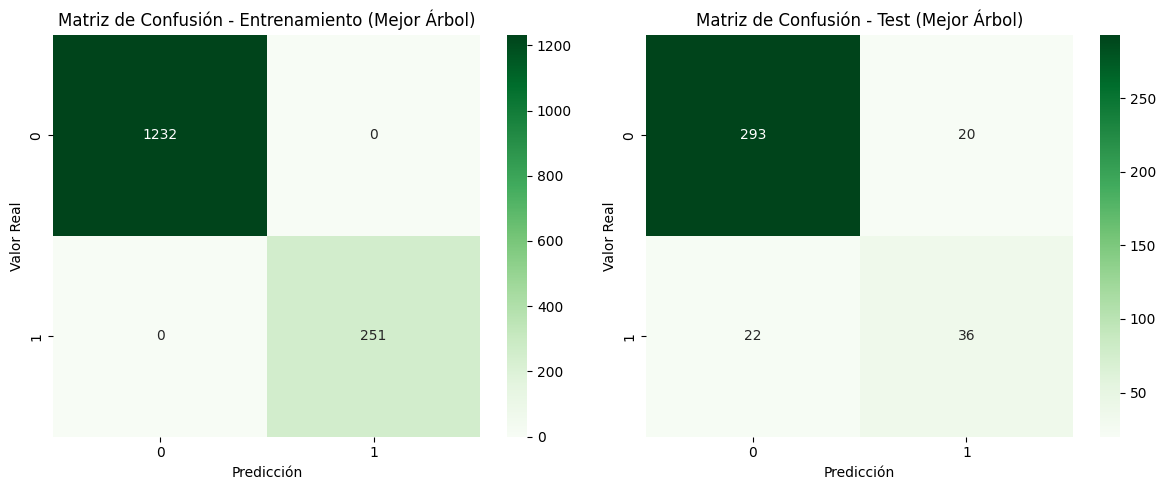

In [38]:
matrixConfusion = confusion_matrix(y_train, y_train_predicted_tree)
print("\nMatriz de Confusión (Entrenamiento):")
print(matrixConfusion)
sns.heatmap(matrixConfusion, annot=True, fmt='d', cmap='Greens', ax=ax1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión para entrenamiento
sns.heatmap(matrixConfusion, annot=True, fmt='d', cmap='Greens', ax=ax1)
ax1.set_title('Matriz de Confusión - Entrenamiento (Mejor Árbol)')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Valor Real')

matrixConfusion_test = confusion_matrix(y_test, y_test_predicted_tree)

# Matriz de confusión para test
sns.heatmap(matrixConfusion_test, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Matriz de Confusión - Test (Mejor Árbol)')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()


Iniciando búsqueda de hiperparámetros para DecisionTreeClassifier...
Esto puede tardar unos minutos...
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

=== MEJORES HIPERPARÁMETROS PARA ÁRBOL DE DECISIÓN ===
{'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 10}

Mejor score en validación cruzada: 0.8833

=== RESULTADOS DE TODAS LAS CONFIGURACIONES ===
Accuracy promedio: 0.8124
Desviación estándar: 0.0558
Rango: 0.7209 - 0.8833

=== EVALUACIÓN DEL MEJOR MODELO EN CONJUNTO DE ENTRENAMIENTO ===
Accuracy: 0.8928
Precision: 0.8981
Recall: 0.8928
F1-Score: 0.8736

=== EVALUACIÓN DEL MEJOR MODELO EN CONJUNTO DE EVALUACIÓN (TEST) ===
Accuracy: 0.8976
Precision: 0.8940
Recall: 0.8976
F1-Score: 0.8821

Matriz de Confusión (Entrenamiento):
[[1226    6]
 [ 153   98]]

Matriz de Confusión (Test):
[[309   4]
 [ 34  24]]


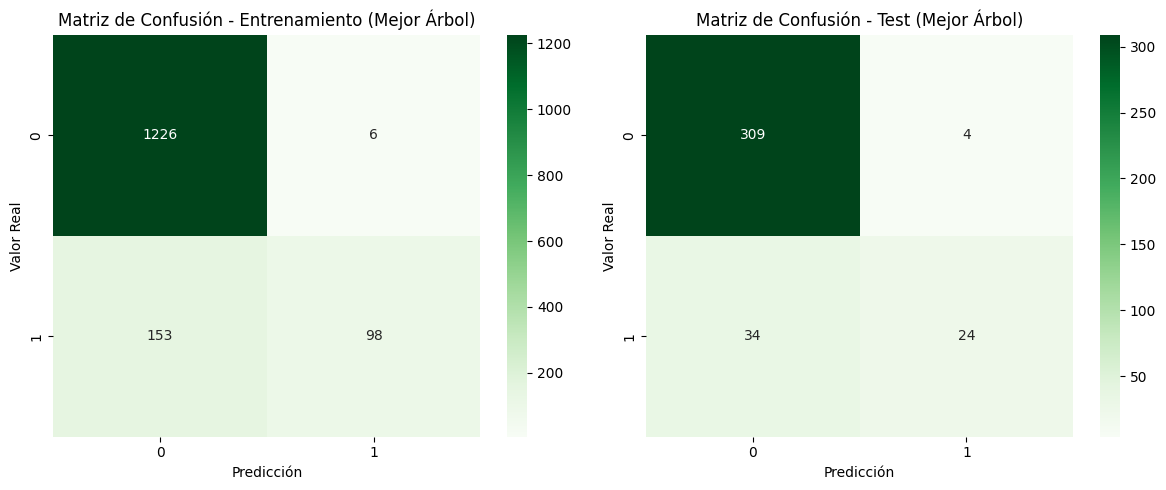


=== REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ===
              precision    recall  f1-score   support

   Rechazado       0.90      0.99      0.94       313
    Otorgado       0.86      0.41      0.56        58

    accuracy                           0.90       371
   macro avg       0.88      0.70      0.75       371
weighted avg       0.89      0.90      0.88       371



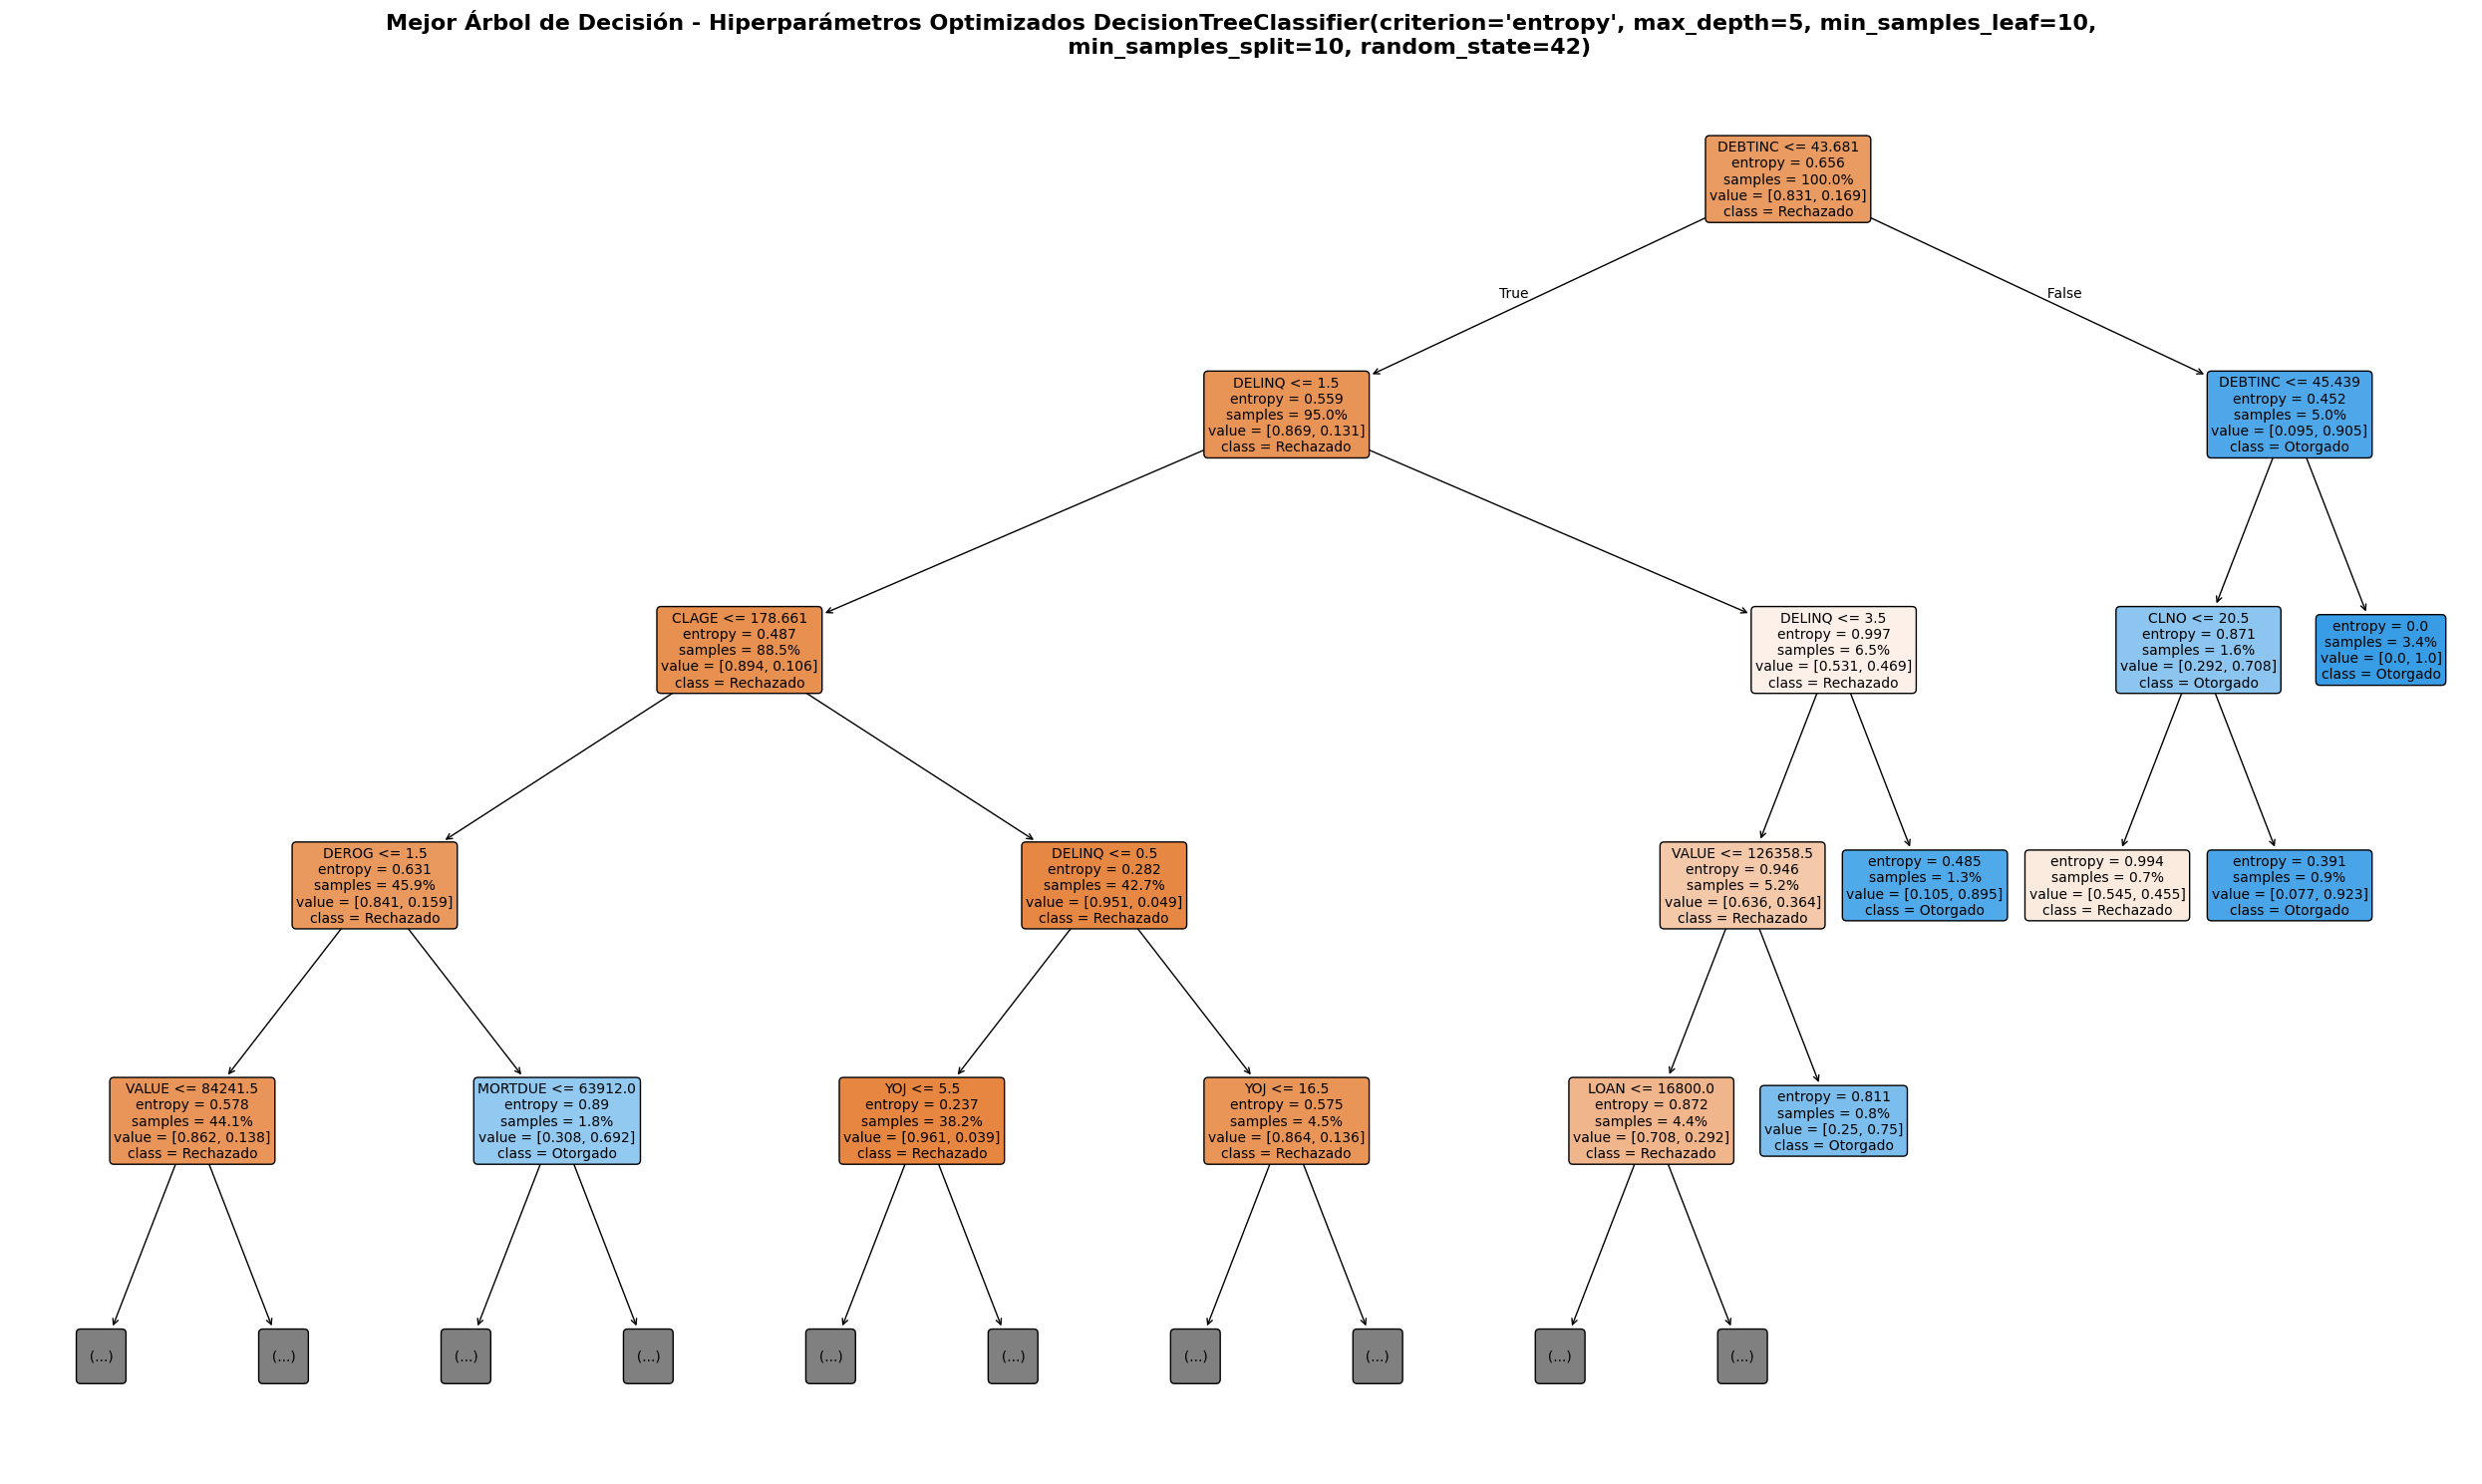


=== IMPORTANCIA DE CARACTERÍSTICAS (MEJOR MODELO) ===
   feature  importance
9  DEBTINC    0.468390
5   DELINQ    0.205821
6    CLAGE    0.091022
4    DEROG    0.080641
2    VALUE    0.065145
3      YOJ    0.031627
0     LOAN    0.023034
1  MORTDUE    0.020400
8     CLNO    0.013919
7     NINQ    0.000000


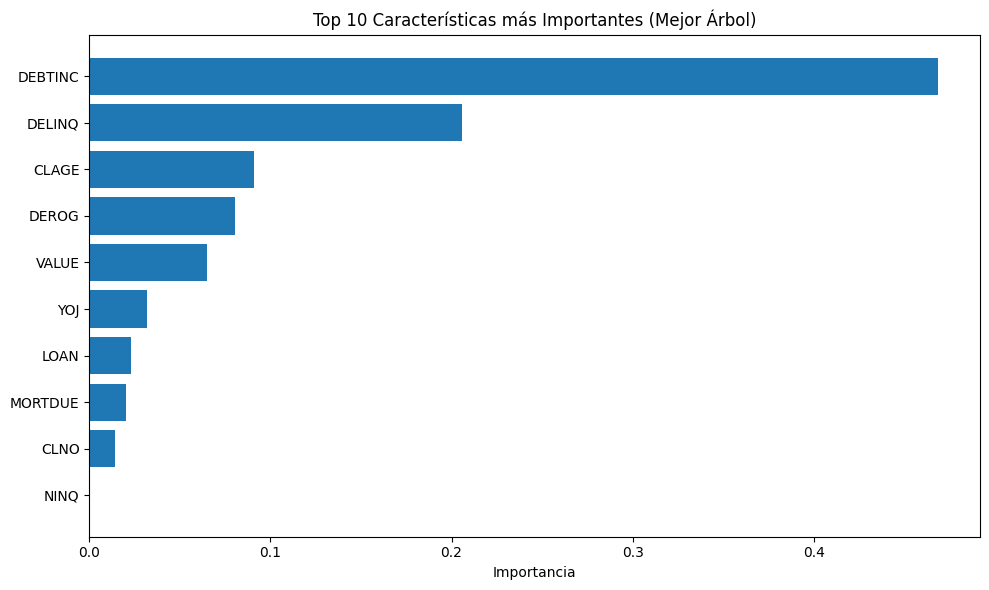

In [39]:
# GridSearchCV para DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Definir el grid de hiperparámetros para el árbol de decisión
param_grid_tree = {
    'criterion': ['gini', 'entropy'],                    # Criterio de partición
    'max_depth': [5, 10, 15, 20, None],                 # Profundidad máxima
    'min_samples_split': [10, 20, 50],                  # Mínimo de muestras para dividir
    'min_samples_leaf': [5, 10, 20],                    # Mínimo de muestras en hoja
    'max_features': ['sqrt', 'log2', None],             # Número máximo de características
    'class_weight': [None, 'balanced']                  # Balanceo de clases
}

# Crear el clasificador base
tree_classifier = tree.DecisionTreeClassifier(random_state=42)

# Crear GridSearchCV
grid_search_tree = GridSearchCV(
    estimator=tree_classifier,
    param_grid=param_grid_tree,
    cv=5,                        # 5-fold cross validation
    scoring='accuracy',          # Métrica para evaluar
    n_jobs=-1,                  # Usar todos los cores disponibles
    verbose=1                   # Mostrar progreso
)

print("Iniciando búsqueda de hiperparámetros para DecisionTreeClassifier...")
print("Esto puede tardar unos minutos...")

# Entrenar (esto prueba todas las combinaciones)
grid_search_tree.fit(X_train, y_train)

# Obtener el mejor modelo
best_tree = grid_search_tree.best_estimator_

# Hacer predicciones con el mejor modelo
y_train_pred_best_tree = best_tree.predict(X_train)
y_test_pred_best_tree = best_tree.predict(X_test)

print("\n=== MEJORES HIPERPARÁMETROS PARA ÁRBOL DE DECISIÓN ===")
print(grid_search_tree.best_params_)
print(f"\nMejor score en validación cruzada: {grid_search_tree.best_score_:.4f}")

# Mostrar accuracy promedio y varianza para todas las configuraciones
print("\n=== RESULTADOS DE TODAS LAS CONFIGURACIONES ===")
results_df = pd.DataFrame(grid_search_tree.cv_results_)
print(f"Accuracy promedio: {results_df['mean_test_score'].mean():.4f}")
print(f"Desviación estándar: {results_df['mean_test_score'].std():.4f}")
print(f"Rango: {results_df['mean_test_score'].min():.4f} - {results_df['mean_test_score'].max():.4f}")

print("\n=== EVALUACIÓN DEL MEJOR MODELO EN CONJUNTO DE ENTRENAMIENTO ===")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred_best_tree):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred_best_tree, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred_best_tree, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred_best_tree, average='weighted'):.4f}")

print("\n=== EVALUACIÓN DEL MEJOR MODELO EN CONJUNTO DE EVALUACIÓN (TEST) ===")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_best_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred_best_tree, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred_best_tree, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred_best_tree, average='weighted'):.4f}")

# Matrices de confusión
print("\nMatriz de Confusión (Entrenamiento):")
cm_train_best_tree = confusion_matrix(y_train, y_train_pred_best_tree)
print(cm_train_best_tree)

print("\nMatriz de Confusión (Test):")
cm_test_best_tree = confusion_matrix(y_test, y_test_pred_best_tree)
print(cm_test_best_tree)

# Visualización de las matrices de confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión para entrenamiento
sns.heatmap(cm_train_best_tree, annot=True, fmt='d', cmap='Greens', ax=ax1)
ax1.set_title('Matriz de Confusión - Entrenamiento (Mejor Árbol)')
ax1.set_xlabel('Predicción')
ax1.set_ylabel('Valor Real')

# Matriz de confusión para test
sns.heatmap(cm_test_best_tree, annot=True, fmt='d', cmap='Greens', ax=ax2)
ax2.set_title('Matriz de Confusión - Test (Mejor Árbol)')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

print("\n=== REPORTE DE CLASIFICACIÓN DETALLADO (TEST) ===")
print(classification_report(y_test, y_test_pred_best_tree, target_names=['Rechazado', 'Otorgado']))

# Visualizar el mejor árbol
plt.figure(figsize=(25, 15))
tree.plot_tree(best_tree,
               feature_names=X_train.columns,
               class_names=['Rechazado', 'Otorgado'],
               filled=True,
               rounded=True,
               max_depth=4,
               fontsize=10,
               impurity=True,
               proportion=True)

plt.title(f"Mejor Árbol de Decisión - Hiperparámetros Optimizados {best_tree}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Importancia de características del mejor modelo
print("\n=== IMPORTANCIA DE CARACTERÍSTICAS (MEJOR MODELO) ===")
feature_importance_best = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_best)

# Gráfico de importancia
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_best['feature'][:10], feature_importance_best['importance'][:10])
plt.xlabel('Importancia')
plt.title('Top 10 Características más Importantes (Mejor Árbol)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()